# 🏦 Modelo v4 — Teoría de Colas para Agencias Bancarias
## M/M/s → M/G/s | Optimización · Simulación Monte Carlo · Análisis de Sensibilidad

**Objetivo:** Dimensionamiento óptimo de auxiliares de operaciones por agencia y franja horaria,
minimizando el costo total mientras se garantizan niveles de servicio aceptables.

---
### 📋 Flujo del modelo
```
Datos (df.csv + dist_agencias.csv)
  → μ y C_s² ponderados por hora
    → M/M/s por hora con restricciones operativas
      → Extensión M/G/s (Allen-Cunneen)
        → Optimización de servidores por hora
          → Consolidación por turnos (T1: 09-14 | T2: 14-18)
            → Simulación Monte Carlo (validación)
              → Análisis de Sensibilidad
                → Outputs: tabla hora / turno / decisiones

## PASO 1 — Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import warnings
import time
from math import factorial
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 250)

# ── Parámetros globales del modelo ──────────────────────────────────────────
WQ_MAX_MIN   = 5.0     # Wq máximo aceptable (minutos)
RHO_MAX      = 0.85    # Utilización máxima aceptable
ALPHA        = 2.5     # Factor de penalización (α ∈ [2, 3])
N_SIM        = 3_000   # Iteraciones Monte Carlo por escenario
MAX_SERVERS  = 15      # Límite superior de búsqueda en optimización
RANDOM_SEED  = 42
np.random.seed(RANDOM_SEED)

print('✅ Librerías y parámetros cargados correctamente')
print(f'   Wq_max = {WQ_MAX_MIN} min | ρ_max = {RHO_MAX} | α = {ALPHA} | Simulaciones = {N_SIM:,}')

✅ Librerías y parámetros cargados correctamente
   Wq_max = 5.0 min | ρ_max = 0.85 | α = 2.5 | Simulaciones = 3,000


## PASO 2 — Carga de datos

In [2]:
df   = pd.read_csv('df.csv')
dist = pd.read_csv('dist_agencias.csv')

print('=== df.csv ===')
print(f'Dimensiones: {df.shape}')
print(df.to_string(index=False))
print()
print('=== dist_agencias.csv ===')
print(f'Dimensiones: {dist.shape}')
print(dist[['agencia','tipo_ope']].drop_duplicates().to_string(index=False))

=== df.csv ===
Dimensiones: (20, 6)
                              agencia                hora  lambda  servidores      Cs      Cq
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59 31.6400           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 15:00:00 - 15:59:59 44.2300           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 16:00:00 - 16:59:59 59.1100           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES LOS GUINDALES 17:00:00 - 17:59:59 65.2800           5 13.6400 27.2900
AG.PARQUE DE LAS FLORES 

## PASO 3 — Parámetros de servicio por tipo de operación

In [3]:
# Tiempo promedio de servicio por tipo de operación (minutos)
T_SERVICIO = {
    'DEPOSITO':                         2.23,
    'COBRANZA LOCALES OTRAS AGENCIAS':  3.82,
    'COBRANZAS':                        3.82,
    'RETIRO':                           2.54,
    'DESEMBOLSO':                       15.21,
    'APERTURA':                        11.05
}

# Varianza del tiempo de servicio (minutos²)
# Operaciones simples → baja varianza | complejas → alta varianza
VAR_SERVICIO = {
    'DEPOSITO':                         1.47,
    'COBRANZA LOCALES OTRAS AGENCIAS':  4.87,
    'COBRANZAS':                        4.87,
    'RETIRO':                           1.29,
    'DESEMBOLSO':                      9.69,
    'APERTURA':                        7.86
}

dist['t_s'] = dist['tipo_ope'].map(T_SERVICIO)
dist['var_s'] = dist['tipo_ope'].map(VAR_SERVICIO)


print('Parámetros de servicio asignados:')
resumen = dist[['tipo_ope','t_s','var_s']].drop_duplicates('tipo_ope').copy()
resumen['mu_individual'] = (60 / resumen['t_s']).round(2)
resumen['C_s2']          = (resumen['var_s'] / resumen['t_s']**2).round(3)
print(resumen.to_string(index=False))

Parámetros de servicio asignados:
                       tipo_ope     t_s  var_s  mu_individual   C_s2
                       DEPOSITO  2.2300 1.4700        26.9100 0.2960
COBRANZA LOCALES OTRAS AGENCIAS  3.8200 4.8700        15.7100 0.3340
                      COBRANZAS  3.8200 4.8700        15.7100 0.3340
                         RETIRO  2.5400 1.2900        23.6200 0.2000
                     DESEMBOLSO 15.2100 9.6900         3.9400 0.0420
                       APERTURA 11.0500 7.8600         5.4300 0.0640


## PASO 4 — Análisis Exploratorio de Datos (EDA)

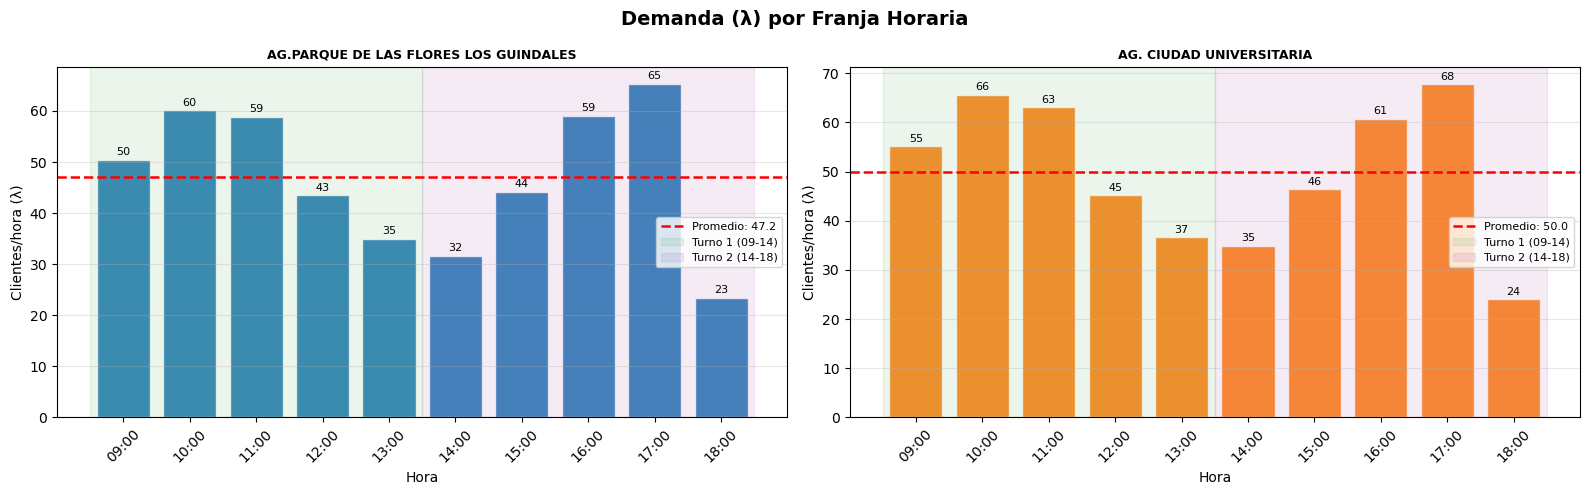

In [4]:
cols_horas = [c for c in dist.columns if ':' in c]
agencias   = df['agencia'].unique()
COLORES    = ['#1f77b4', '#ff7f0e']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Demanda (λ) por Franja Horaria', fontsize=14, fontweight='bold')

for ax, agencia, color in zip(axes, agencias, COLORES):
    sub  = df[df['agencia'] == agencia].copy()
    horas = [h[:5] for h in sub['hora']]
    bars  = ax.bar(horas, sub['lambda'], color=color, edgecolor='white', alpha=0.85)
    ax.axhline(sub['lambda'].mean(), color='red', linestyle='--', lw=1.8,
               label=f"Promedio: {sub['lambda'].mean():.1f}")
    ax.axvspan(-0.5, 4.5, alpha=0.08, color='green', label='Turno 1 (09-14)')
    ax.axvspan(4.5, 9.5, alpha=0.08, color='purple', label='Turno 2 (14-18)')
    ax.set_title(agencia[:40], fontsize=9, fontweight='bold')
    ax.set_xlabel('Hora')
    ax.set_ylabel('Clientes/hora (λ)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, sub['lambda']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.0f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
# plt.savefig('eda_demanda.png', dpi=130, bbox_inches='tight')
plt.show()
# print('✅ Gráfico guardado: eda_demanda.png')

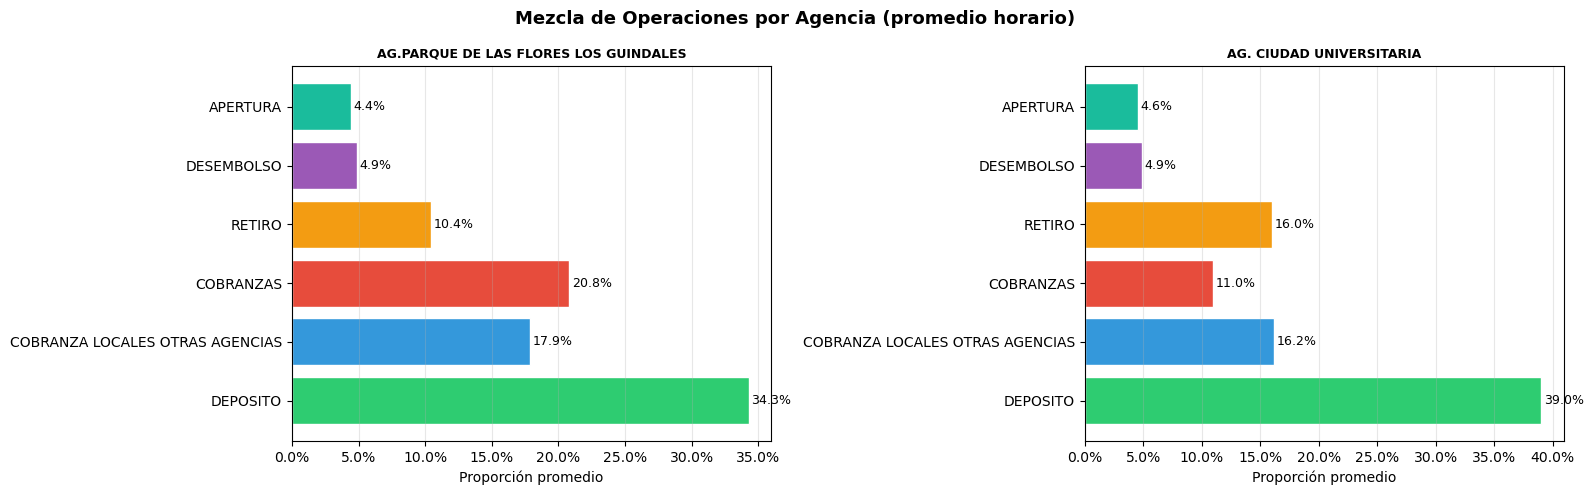

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Mezcla de Operaciones por Agencia (promedio horario)', fontsize=13, fontweight='bold')
PALETTE = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6','#1abc9c']

for ax, agencia in zip(axes, agencias):
    sub = dist[dist['agencia'] == agencia].copy()
    sub['prop_media'] = sub[cols_horas].mean(axis=1)
    bars = ax.barh(sub['tipo_ope'], sub['prop_media'], color=PALETTE[:len(sub)], edgecolor='white')
    for bar, val in zip(bars, sub['prop_media']):
        ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                f'{val:.1%}', va='center', fontsize=9)
    ax.set_title(agencia[:40], fontsize=9, fontweight='bold')
    ax.set_xlabel('Proporción promedio')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
# plt.savefig('eda_operaciones.png', dpi=130, bbox_inches='tight')
plt.show()
# print('✅ Gráfico guardado: eda_operaciones.png')

## PASO 5 — Cálculo de μ ponderado y C_s² por hora

**Fórmulas:**
```
E[T]    = Σ p_k(hora) × t_k          # tiempo promedio ponderado (min)
μ       = 60 / E[T]                   # clientes/hora por servidor
E[T²]   = Σ p_k × (Var_k + t_k²)     # ley de expectativas totales
Var[T]  = E[T²] - E[T]²
C_s²    = Var[T] / E[T]²              # coeficiente de variación al cuadrado
```

In [6]:
def calcular_mu_C_s2(df_base, dist_df, cols_horas):
    """Calcula μ y C_s² ponderados por mezcla de operaciones para cada (agencia, hora)."""
    rows = []
    for _, row in df_base.iterrows():
        agencia = row['agencia']
        hora    = row['hora']
        d       = dist_df[dist_df['agencia'] == agencia]

        if hora not in d.columns:
            rows.append({'agencia': agencia, 'hora': hora, 'mu': np.nan, 'C_s2': np.nan, 'E_T': np.nan})
            continue

        probs = d[hora].values.astype(float)
        ts    = d['t_s'].values.astype(float)
        var_s = d['var_s'].values.astype(float)
        total = probs.sum()

        if total == 0 or np.isnan(total):
            rows.append({'agencia': agencia, 'hora': hora, 'mu': np.nan, 'C_s2': np.nan, 'E_T': np.nan})
            continue

        E_T   = np.dot(probs, ts) / total
        E_T2  = np.dot(probs, var_s + ts**2) / total
        Var_T = max(E_T2 - E_T**2, 0)
        C_s2  = Var_T / E_T**2 if E_T > 0 else np.nan
        mu    = 60.0 / E_T    if E_T > 0 else np.nan
        rows.append({'agencia': agencia, 'hora': hora, 'mu': mu, 'C_s2': C_s2, 'E_T': E_T})

    return pd.DataFrame(rows)


mu_df = calcular_mu_C_s2(df, dist, cols_horas)
df2   = df.merge(mu_df, on=['agencia','hora'], how='left')

print('μ y C_s² calculados por agencia-hora:')
print(df2[['agencia','hora','lambda','servidores','mu','C_s2','E_T']].to_string(index=False))

μ y C_s² calculados por agencia-hora:
                              agencia                hora  lambda  servidores      mu   C_s2    E_T
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000           5 16.0984 0.7744 3.7271
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200           5 15.7618 0.8252 3.8067
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000           5 15.6588 0.8436 3.8317
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800           5 15.0392 0.8624 3.9896
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000           5 14.8599 0.8135 4.0377
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59 31.6400           5 15.2598 0.8256 3.9319
AG.PARQUE DE LAS FLORES LOS GUINDALES 15:00:00 - 15:59:59 44.2300           5 15.8730 0.8098 3.7800
AG.PARQUE DE LAS FLORES LOS GUINDALES 16:00:00 - 16:59:59 59.1100           5 15.7302 0.8396 3.8143
AG.PARQUE DE LAS FLORES LOS GUINDALES 17:00:00 - 17:59:59 65.2

## PASO 6 — Modelamiento M/M/s con restricciones operativas

**Restricciones obligatorias:**
- ρ = λ/(s×μ) < 1 — estabilidad del sistema
- Wq ≤ 5 minutos — nivel de servicio
- ρ ≤ 0.85 — holgura operativa

**Penalización si ρ > 0.85:**  
`CT_ajustado = CT × (1 + α × (ρ − 0.85))`

In [7]:
def mms_metricas(lam, mu, s, Cs, Cq, alpha=ALPHA):
    """
    Calcula métricas completas del modelo M/M/s con restricciones operativas.
    Devuelve dict con NaN si el sistema es inválido o inestable.
    """
    nan_r = dict(rho=np.nan, P0=np.nan, Lq=np.nan, Wq_h=np.nan, Ws_h=np.nan,
                 Ls=np.nan, Wq_m=np.nan, Ws_m=np.nan,
                 serv_ocupados=np.nan, serv_ociosos=np.nan,
                 CTS=np.nan, CTS_idle=np.nan, CTQ=np.nan, CT=np.nan,
                 CT_ajustado=np.nan, cumple_Wq=False, cumple_rho=False, valido=False)

    if mu <= 0 or s <= 0 or lam < 0:
        return nan_r

    s   = int(s)
    rho = lam / (s * mu)
    r   = lam / mu

    if rho >= 1:
        return {**nan_r, 'rho': rho, 'valido': False}

    # P0
    sum_k  = sum(r**k / factorial(k) for k in range(s))
    term_s = (r**s) / (factorial(s) * (1 - rho))
    P0     = 1.0 / (sum_k + term_s)

    # Métricas de cola
    Lq   = P0 * (r**s) * rho / (factorial(s) * (1 - rho)**2)
    Wq_h = Lq / lam if lam > 0 else 0
    Ws_h = Wq_h + 1.0 / mu # espera + atencion
    Ls   = lam * Ws_h
    Wq_m = Wq_h * 60
    Ws_m = Ws_h * 60

    # Servidores
    serv_ocupados = Ls - Lq
    serv_ociosos  = s - serv_ocupados

    # Costos base
    CTS      = (Cs + Cq) * serv_ocupados
    CTS_idle = Cs * max(serv_ociosos, 0)
    CTQ      = lam * Cq * Wq_h
    CT       = CTS + CTS_idle + CTQ

    # Restricciones
    cumple_Wq  = Wq_m <= WQ_MAX_MIN # el cliente no debe esperar mas de 5 minutos
    cumple_rho = rho  <= RHO_MAX # No debemos operar al limite maximo al 85%

    # Penalización por ρ > 0.85
    penalizacion = (1 + alpha * (rho - RHO_MAX)) if rho > RHO_MAX else 1.0
    CT_ajustado  = CT * penalizacion

    return dict(
        rho=rho, P0=P0, Lq=Lq, Wq_h=Wq_h, Ws_h=Ws_h,
        Ls=Ls, Wq_m=Wq_m, Ws_m=Ws_m,
        serv_ocupados=serv_ocupados, serv_ociosos=serv_ociosos,
        CTS=CTS, CTS_idle=CTS_idle, CTQ=CTQ, CT=CT,
        CT_ajustado=CT_ajustado,
        cumple_Wq=cumple_Wq, cumple_rho=cumple_rho,
        valido=cumple_Wq and rho < 1
    )


print('✅ Función M/M/s definida')
# Test rápido
test = mms_metricas(60, 20, 5, 13.64, 27.29)
print(f'   Test (λ=60, μ=20, s=5): ρ={test["rho"]:.3f} | Wq={test["Wq_m"]:.2f} min | CT={test["CT"]:.2f}')

✅ Función M/M/s definida
   Test (λ=60, μ=20, s=5): ρ=0.600 | Wq=0.35 min | CT=159.74


In [8]:
# Aplicar M/M/s con servidores actuales
mms_rows = []
for _, row in df2.iterrows():
    m = mms_metricas(row['lambda'], row['mu'], row['servidores'], row['Cs'], row['Cq'])
    mms_rows.append({**row.to_dict(), **{f'mms_{k}': v for k, v in m.items()}})

res = pd.DataFrame(mms_rows)

print('=== M/M/s — Servidores Actuales ===')
cols_show = ['agencia','hora','lambda','servidores','mu','mms_rho','mms_Wq_m',
             'mms_CT','mms_cumple_Wq','mms_cumple_rho']
print(res[cols_show].to_string(index=False))

=== M/M/s — Servidores Actuales ===
                              agencia                hora  lambda  servidores      mu  mms_rho  mms_Wq_m   mms_CT  mms_cumple_Wq  mms_cumple_rho
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000           5 16.0984   0.6274    0.5430 166.2790           True            True
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200           5 15.7618   0.7629    1.5562 214.8466           True            True
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000           5 15.6588   0.7523    1.4412 209.4602           True            True
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800           5 15.0392   0.5782    0.3974 154.9564           True            True
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000           5 14.8599   0.4711    0.1625 135.0635           True            True
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59 31.6400           5 15.2598   0.4147

## PASO 7 — Extensión M/G/s (corrección Allen-Cunneen)

**Corrección:**  
```
Wq_MGS = Wq_MMS × (1 + C_s²) / 2
```
Luego se actualizan Ws, Lq, Ls y CT.

In [9]:
def aplicar_allen_cunneen(mms_dict, lam, mu, s, Cs, Cq, C_s2):
    """Aplica corrección Allen-Cunneen al resultado M/M/s."""
    if not mms_dict or np.isnan(mms_dict.get('Wq_h', np.nan)):
        return {k: np.nan for k in ['mgs_Wq_m','mgs_Wq_h','mgs_Ws_m','mgs_Lq','mgs_Ls','mgs_CT','mgs_CT_ajustado']}

    C_s2  = max(C_s2, 0) if not np.isnan(C_s2) else 1.0
    factor = (1 + C_s2) / 2

    Wq_h_mgs = mms_dict['Wq_h'] * factor
    Ws_h_mgs = Wq_h_mgs + 1.0 / mu
    Lq_mgs   = lam * Wq_h_mgs
    Ls_mgs   = lam * Ws_h_mgs
    Wq_m_mgs = Wq_h_mgs * 60
    Ws_m_mgs = Ws_h_mgs * 60

    serv_ocu = Ls_mgs - Lq_mgs
    serv_oci = s - serv_ocu
    CTS      = (Cs + Cq) * serv_ocu
    CTS_idle = Cs * max(serv_oci, 0)
    CTQ      = lam * Cq * Wq_h_mgs
    CT       = CTS + CTS_idle + CTQ

    rho = mms_dict['rho']
    penalizacion = (1 + ALPHA * (rho - RHO_MAX)) if rho > RHO_MAX else 1.0
    CT_ajustado  = CT * penalizacion

    return dict(
        mgs_Wq_m=Wq_m_mgs, mgs_Wq_h=Wq_h_mgs,
        mgs_Ws_m=Ws_m_mgs, mgs_Lq=Lq_mgs,
        mgs_Ls=Ls_mgs, mgs_CT=CT,
        mgs_CT_ajustado=CT_ajustado,
        mgs_cumple_Wq=(Wq_m_mgs <= WQ_MAX_MIN)
    )


# Aplicar M/G/s a servidores actuales
mgs_data = []
for _, row in res.iterrows():
    mms_dict = {k.replace('mms_',''):row[k] for k in res.columns if k.startswith('mms_')}
    mgs = aplicar_allen_cunneen(mms_dict, row['lambda'], row['mu'],
                                 int(row['servidores']), row['Cs'], row['Cq'], row['C_s2'])
    mgs_data.append(mgs)

res = pd.concat([res, pd.DataFrame(mgs_data)], axis=1)
print('=== M/G/s — Allen-Cunneen aplicado ===')
print(res[['agencia','hora','lambda','servidores','mms_Wq_m','mgs_Wq_m','mms_CT','mgs_CT']].to_string(index=False))

=== M/G/s — Allen-Cunneen aplicado ===
                              agencia                hora  lambda  servidores  mms_Wq_m  mgs_Wq_m   mms_CT   mgs_CT
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000           5    0.5430    0.4817 166.2790 164.8719
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200           5    1.5562    1.4203 214.8466 211.1281
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000           5    1.4412    1.3285 209.4602 206.4403
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800           5    0.3974    0.3700 154.9564 154.4159
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000           5    0.1625    0.1473 135.0635 134.8223
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59 31.6400           5    0.0913    0.0834 126.0982 125.9836
AG.PARQUE DE LAS FLORES LOS GUINDALES 15:00:00 - 15:59:59 44.2300           5    0.3186    0.2883 150.6533 150.0437
AG.PARQUE DE LAS FLORES LOS GUIND

In [10]:
def optimizar_servidores(lam, mu, Cs, Cq, C_s2, s_max=MAX_SERVERS):
    """
    Encuentra el número óptimo de servidores que:
    1. Garantiza Wq ≤ WQ_MAX_MIN (M/G/s)
    2. Garantiza ρ < 1
    3. Minimiza CT_ajustado (M/G/s)
    """
    if np.isnan(mu) or mu <= 0 or np.isnan(lam) or lam <= 0:
        return None

    s_min = max(1, int(np.ceil(lam / mu)) + 1)  # mínimo para estabilidad
    best  = None

    for s in range(s_min, s_max + 1):
        m = mms_metricas(lam, mu, s, Cs, Cq)
        if np.isnan(m['Wq_h']):
            continue

        # Allen-Cunneen
        mgs = aplicar_allen_cunneen(m, lam, mu, s, Cs, Cq, C_s2)
        Wq_m = mgs['mgs_Wq_m']
        CT_a = mgs['mgs_CT_ajustado']

        if Wq_m <= WQ_MAX_MIN and m['rho'] < 1:
            if best is None or CT_a < best['CT_ajustado']:
                best = {
                    's_opt': s,
                    'rho_opt': m['rho'],
                    'Wq_m_mms_opt': m['Wq_m'],
                    'Wq_m_mgs_opt': Wq_m,
                    'CT_opt': mgs['mgs_CT'],
                    'CT_ajustado': CT_a,
                    'cumple_rho': m['cumple_rho']
                }

    return best


opt_rows = []
for _, row in res.iterrows():
    opt = optimizar_servidores(row['lambda'], row['mu'], row['Cs'], row['Cq'], row['C_s2'])
    if opt:
        opt_rows.append({**row.to_dict(), **opt})
    else:
        opt_rows.append({**row.to_dict(), 's_opt': np.nan})

res = pd.DataFrame(opt_rows)
print('=== Optimización por hora (s_opt) ===')
print(res[['agencia','hora','lambda','servidores','s_opt','rho_opt','Wq_m_mgs_opt','CT_opt']].to_string(index=False))

=== Optimización por hora (s_opt) ===
                              agencia                hora  lambda  servidores  s_opt  rho_opt  Wq_m_mgs_opt   CT_opt
AG.PARQUE DE LAS FLORES LOS GUINDALES 09:00:00 - 09:59:59 50.5000           5      5   0.6274        0.4817 164.8719
AG.PARQUE DE LAS FLORES LOS GUINDALES 10:00:00 - 10:59:59 60.1200           5      6   0.6357        0.3838 196.4261
AG.PARQUE DE LAS FLORES LOS GUINDALES 11:00:00 - 11:59:59 58.9000           5      6   0.6269        0.3627 194.2078
AG.PARQUE DE LAS FLORES LOS GUINDALES 12:00:00 - 12:59:59 43.4800           5      5   0.5782        0.3700 154.4159
AG.PARQUE DE LAS FLORES LOS GUINDALES 13:00:00 - 13:59:59 35.0000           5      4   0.5888        0.6076 128.5102
AG.PARQUE DE LAS FLORES LOS GUINDALES 14:00:00 - 14:59:59 31.6400           5      4   0.5184        0.3585 116.3034
AG.PARQUE DE LAS FLORES LOS GUINDALES 15:00:00 - 15:59:59 44.2300           5      5   0.5573        0.2883 150.0437
AG.PARQUE DE LAS FLORES LO

In [11]:
def asignar_turno(hora):
    h = int(hora[:2])
    if 9 <= h < 14:
        return 'Turno 1 (09-14)'
    elif 14 <= h < 19:
        return 'Turno 2 (14-18)'
    return 'Otro'

res['turno'] = res['hora'].apply(asignar_turno)

# Promedios ponderados por λ dentro de cada turno
turno_rows = []
for (agencia, turno), grp in res.groupby(['agencia','turno']):
    lam_total = grp['lambda'].sum()
    w = grp['lambda'] / lam_total if lam_total > 0 else pd.Series([1/len(grp)]*len(grp), index=grp.index)

    mu_pond  = (grp['mu']   * w).sum()
    Cs2_pond = (grp['C_s2'] * w).sum()
    Cs_val   = grp['Cs'].iloc[0]
    Cq_val   = grp['Cq'].iloc[0]
    lam_pond = grp['lambda'].mean()

    opt_t = optimizar_servidores(lam_pond, mu_pond, Cs_val, Cq_val, Cs2_pond)
    s_opt_t = opt_t['s_opt'] if opt_t else np.nan

    # Aplicar s_opt_t a todas las horas del turno
    ct_turno = 0
    wq_list  = []
    rho_list = []
    for _, row_h in grp.iterrows():
        if not np.isnan(s_opt_t):
            m_h  = mms_metricas(row_h['lambda'], row_h['mu'], int(s_opt_t), Cs_val, Cq_val)
            mgs_h = aplicar_allen_cunneen(m_h, row_h['lambda'], row_h['mu'],
                                          int(s_opt_t), Cs_val, Cq_val, row_h['C_s2'])
            ct_turno += mgs_h.get('mgs_CT', 0)
            wq_list.append(mgs_h.get('mgs_Wq_m', np.nan))
            rho_list.append(m_h.get('rho', np.nan))

    ct_actual_t = grp['mgs_CT'].sum()
    ahorro      = ct_actual_t - ct_turno
    s_actual_t  = grp['servidores'].iloc[0]

    if s_opt_t > s_actual_t:
        decision = '🔴 CONTRATAR'
    elif s_opt_t < s_actual_t:
        decision = '🟢 REDUCIR'
    else:
        decision = '🟡 MANTENER'

    turno_rows.append(dict(
        agencia=agencia, turno=turno,
        n_horas=len(grp),
        lambda_pond=round(lam_pond, 2),
        mu_pond=round(mu_pond, 2),
        s_actual=int(s_actual_t),
        s_opt_turno=int(s_opt_t) if not np.isnan(s_opt_t) else np.nan,
        Wq_prom_mgs=round(np.nanmean(wq_list), 3),
        rho_prom=round(np.nanmean(rho_list), 3),
        CT_actual_turno=round(ct_actual_t, 2),
        CT_opt_turno=round(ct_turno, 2),
        ahorro=round(ahorro, 2),
        decision=decision
    ))

df_turnos = pd.DataFrame(turno_rows)
print('=== Consolidación por Turnos ===')
print(df_turnos.to_string(index=False))

=== Consolidación por Turnos ===
                              agencia           turno  n_horas  lambda_pond  mu_pond  s_actual  s_opt_turno  Wq_prom_mgs  rho_prom  CT_actual_turno  CT_opt_turno    ahorro   decision
             AG. CIUDAD UNIVERSITARIA Turno 1 (09-14)        5      53.1700  16.4200         6            5       0.8650    0.6480         823.4200      841.7800  -18.3600  🟢 REDUCIR
             AG. CIUDAD UNIVERSITARIA Turno 2 (14-18)        5      46.7900  15.0200         6            5       5.1420    0.6310         850.5600     1447.2600 -596.7000  🟢 REDUCIR
AG.PARQUE DE LAS FLORES LOS GUINDALES Turno 1 (09-14)        5      49.6000  15.5500         5            5       0.7500    0.6380         871.6800      871.6800    0.0000 🟡 MANTENER
AG.PARQUE DE LAS FLORES LOS GUINDALES Turno 2 (14-18)        5      44.7400  14.8600         5            5       1.7530    0.6070        1006.1500     1006.1500    0.0000 🟡 MANTENER
